In [ ]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns   
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def wrangle_meter_data(df):
    """
    Prepare meter data for classification model training.
    
    Args:
        df (pd.DataFrame): Raw meter data.
        scale_features (bool): Whether to scale numeric features.
        
    Returns:
        X (pd.DataFrame or np.array): Feature matrix ready for training.
        y (pd.Series): Target variable IsAtRisk.
    """

    # If DSR_percent is less than 85, 'IsAtRisk' will be 1 (True), otherwise it will be 0 (False).
    df['IsAtRisk'] = (df['DSR_percent'] < 85).astype(int)
    
    # Drop columns that can leak the target
    drop_cols = ['MeterID', 'Latitude', 'Longitude', 'ExpectedReads', 'ActualReads', 'DSR_percent']
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])
    
    if 'LidType' in df.columns:
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded = encoder.fit_transform(df[['LidType']])
        df[[*encoder.get_feature_names_out(['LidType'])]] = encoded
        df = df.drop('LidType', axis=1)
    
    
    # Separate target
    y = df['IsAtRisk']
    X = df.drop(columns=['IsAtRisk'])
    
    return X, y

# -----------------------------
# Load Excel file
# -----------------------------
df = pd.read_excel("C:/Users/hp/Documents/Netmore Task/data/Raw Data set.xlsx")
# Create the 'IsAtRisk' column based on the DSR_percent


# Prepare data for modeling
X, y = wrangle_meter_data(df)



# Check the processed data
print(X.head())
print(y.head())


   RSSI_dBm  SNR_dB  SpreadingFactor  Depth_mm  \
0     -84.9    10.9               11       450   
1     -84.2    11.6                9       450   
2     -81.9    12.8                8       450   
3     -83.5    14.5                8       400   
4     -82.4     9.0                9       800   

   DistanceToNearestGateway (meters)  LidType_Composite  LidType_Plastic  
0                                147                1.0              0.0  
1                                 95                0.0              1.0  
2                                 63                1.0              0.0  
3                                 78                0.0              1.0  
4                                 76                0.0              1.0  
0    0
1    0
2    0
3    0
4    0
Name: IsAtRisk, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# X, y are the wrangled features and target from your training dataset

# Split into train and validation (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class distribution consistent
)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Training class distribution:\n", y_train.value_counts(normalize=True))
print("Validation class distribution:\n", y_val.value_counts(normalize=True))


df_test = pd.read_excel("C:/Users/hp/Documents/Netmore Task/data/Test Data.xlsx")
# Create the 'IsAtRisk' column based on the DSR_percent
# If DSR_percent is less than 85, 'IsAtRisk' will be 1 (True), otherwise it will be 0 (False).
df_test['IsAtRisk'] = (df_test['DSR_percent'] < 85).astype(int)
# Prepare data for modeling
X_test, y_test = wrangle_meter_data(df_test)

y_test.head()
X_test.head()
y_test.value_counts()

X_test = X_test[X_train.columns]


Training set shape: (4000, 7)
Validation set shape: (1000, 7)
Training class distribution:
 IsAtRisk
1    0.888
0    0.112
Name: proportion, dtype: float64
Validation class distribution:
 IsAtRisk
1    0.888
0    0.112
Name: proportion, dtype: float64


In [3]:
import os
import joblib
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, train_test_split

# ============================================================
# Split Data (if not already split)
# ============================================================
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# ============================================================
# 1️⃣ Build the Random Forest pipeline
# ============================================================
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),  # Optional — for consistent structure
    ('clf', RandomForestClassifier(
        class_weight='balanced',   # Handles imbalance internally
        random_state=42,
        n_jobs=-1
    ))
])

# ============================================================
# 2️⃣ Define hyperparameter grid
# ============================================================
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2']
}

# ============================================================
# 3️⃣ Stratified K-Fold (preserves class balance in folds)
# ============================================================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 4️⃣ GridSearchCV (tuning the best hyperparameters)
# ============================================================
grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    scoring='recall',     # Prioritize not missing "at-risk" meters
    cv=kfold,
    n_jobs=-1,
    verbose=2
)

# ============================================================
# 5️⃣ Train GridSearch on imbalanced training data
# ============================================================
grid_search.fit(X_train, y_train)

print("\n=== Best Parameters Found ===")
print(grid_search.best_params_)
print(f"\nBest CV Recall Score: {grid_search.best_score_:.4f}")

# ============================================================
# 6️⃣ Evaluate cross-validation metrics on the best model
# ============================================================
best_rf_model = grid_search.best_estimator_

scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(best_rf_model, X_train, y_train, cv=kfold, scoring=scoring)

print("\n=== Cross-Validation Performance (Best Model) ===")
for metric in scoring:
    print(f"{metric.capitalize():<10}: {cv_results['test_' + metric].mean():.4f} ± {cv_results['test_' + metric].std():.4f}")

# ============================================================
# 7️⃣ Fit best model on the full training data
# ============================================================
best_rf_model.fit(X_train, y_train)

# ============================================================
# 8️⃣ Save the trained best model
# ============================================================
save_path = r"C:\Users\hp\Documents\Netmore Task\src\random_forest_best_pipeline.pkl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(best_rf_model, save_path)

print(f"\n✅ Random Forest (optimized, imbalanced data) trained and saved successfully at:\n{save_path}")


Fitting 5 folds for each of 162 candidates, totalling 810 fits

=== Best Parameters Found ===
{'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}

Best CV Recall Score: 0.9820

=== Cross-Validation Performance (Best Model) ===
Accuracy  : 0.9703 ± 0.0061
Precision : 0.9845 ± 0.0063
Recall    : 0.9820 ± 0.0040
F1        : 0.9832 ± 0.0034

✅ Random Forest (optimized, imbalanced data) trained and saved successfully at:
C:\Users\hp\Documents\Netmore Task\src\random_forest_best_pipeline.pkl


In [4]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

# === 1️⃣ Load the trained model ===
model_path = r"C:\Users\hp\Documents\Netmore Task\src\random_forest_best_pipeline.pkl"
pipeline_rf = joblib.load(model_path)

# === 2️⃣ Predict on test data ===
y_pred = pipeline_rf.predict(X_test)

# === 3️⃣ Evaluate performance ===
print("=== Random Forest Test Set Evaluation ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# === 4️⃣ Focused metrics for 'At-Risk' class (1) ===
print(f"Precision (At-Risk): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (At-Risk):    {recall_score(y_test, y_pred):.4f}")


=== Random Forest Test Set Evaluation ===
Confusion Matrix:
 [[  3   7]
 [  3 187]]

Classification Report:
               precision    recall  f1-score   support

           0     0.5000    0.3000    0.3750        10
           1     0.9639    0.9842    0.9740       190

    accuracy                         0.9500       200
   macro avg     0.7320    0.6421    0.6745       200
weighted avg     0.9407    0.9500    0.9440       200

Precision (At-Risk): 0.9639
Recall (At-Risk):    0.9842


In [5]:
# Get predicted probabilities for positive class (At-Risk)
y_proba = pipeline_rf.predict_proba(X_test)[:, 1]

# Adjust threshold for recall-focus (e.g., 0.35 instead of 0.5)
threshold = 0.35
y_pred_recall_focus = (y_proba >= threshold).astype(int)

# Evaluate again
print("\n=== Recall-Focused Evaluation ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_recall_focus))
print(classification_report(y_test, y_pred_recall_focus, digits=4))
print(f"Precision (At-Risk): {precision_score(y_test, y_pred_recall_focus):.4f}")
print(f"Recall (At-Risk):    {recall_score(y_test, y_pred_recall_focus):.4f}")



=== Recall-Focused Evaluation ===
Confusion Matrix:
 [[  3   7]
 [  2 188]]
              precision    recall  f1-score   support

           0     0.6000    0.3000    0.4000        10
           1     0.9641    0.9895    0.9766       190

    accuracy                         0.9550       200
   macro avg     0.7821    0.6447    0.6883       200
weighted avg     0.9459    0.9550    0.9478       200

Precision (At-Risk): 0.9641
Recall (At-Risk):    0.9895


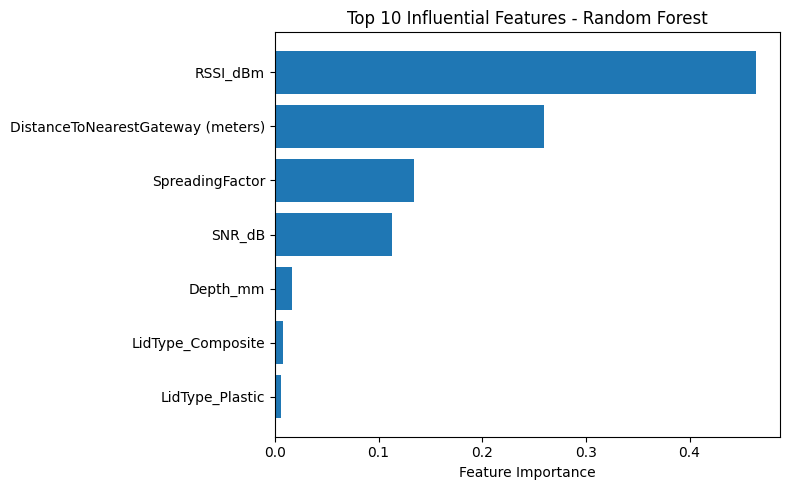

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

# === Load trained Random Forest model ===
rf_model_path = r"C:\Users\hp\Documents\Netmore Task\src\random_forest_best_pipeline.pkl"
pipeline_rf = joblib.load(rf_model_path)

# === Extract feature importances ===
feature_names = X_train.columns
importances = pipeline_rf.named_steps['clf'].feature_importances_

rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# === Plot top 10 features ===
plt.figure(figsize=(8, 5))
plt.barh(rf_importance['Feature'][:10][::-1], rf_importance['Importance'][:10][::-1])
plt.title("Top 10 Influential Features - Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()
